In [1]:
!pip install -q -U transformers accelerate requests

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
from transformers import AutoProcessor, LlavaForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 77.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 28.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
moviepy 1.

In [2]:
MODEL_NAME = "llava-hf/llava-1.5-7b-hf"

processor = AutoProcessor.from_pretrained(MODEL_NAME)
model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float16, device_map="auto"
)
model.eval()

for p in model.parameters():
    p.requires_grad_(False)

print(model.config.text_config.num_hidden_layers, "language model layers,", model.config.text_config.hidden_size, "hidden dim")

processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

32 language model layers, 4096 hidden dim


In [3]:
ln_f = model.model.language_model.norm
lm_head = model.lm_head

found 123287 images under /kaggle/input/datasets/nadaibrahim/coco2014
training on 25 sampled images


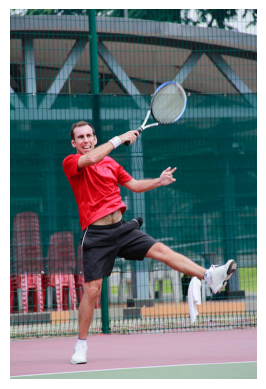

In [4]:
import glob
import random

COCO_ROOT = "/kaggle/input/datasets/nadaibrahim/coco2014"
NUM_IMAGES = 25

random.seed(42)

all_images = sorted(glob.glob(os.path.join(COCO_ROOT, "**", "*.jpg"), recursive=True))
print(f"found {len(all_images)} images under {COCO_ROOT}")
assert len(all_images) > 0, (
    "No .jpg files found under COCO_ROOT -- check the coco2014 dataset (nadaibrahim/coco2014, "
    "same one Track B uses) is added as an Input, and that COCO_ROOT above matches its actual mount path."
)

IMAGE_PATHS = random.sample(all_images, min(NUM_IMAGES, len(all_images)))
print(f"training on {len(IMAGE_PATHS)} sampled images")

CAPTION_PROMPT = "Describe this image in detail."


def load_image(path):
    return Image.open(path).convert("RGB")


def build_inputs(image):
    conversation = [
        {"role": "user", "content": [{"type": "image"}, {"type": "text", "text": CAPTION_PROMPT}]}
    ]
    prompt_text = processor.apply_chat_template(conversation, add_generation_prompt=True)
    return processor(text=prompt_text, images=image, return_tensors="pt").to(model.device, torch.float16)


preview_image = load_image(IMAGE_PATHS[0])
plt.imshow(preview_image)
plt.axis("off")
plt.show()

In [5]:
TRAIN_ON = "all"  # "all" | "text" | "image"


def select_training_positions(input_ids, image_token_positions, mode="all"):
    """Returns the 1D tensor of sequence positions to train the translators on."""
    seq_len = input_ids.shape[-1]
    all_positions = torch.arange(seq_len, device=input_ids.device)
    if mode == "all":
        return all_positions
    elif mode == "image":
        return image_token_positions
    elif mode == "text":
        mask = torch.ones(seq_len, dtype=torch.bool, device=input_ids.device)
        mask[image_token_positions] = False
        return all_positions[mask]
    else:
        raise ValueError(f"unknown TRAIN_ON mode: {mode!r}")

In [6]:
class TunedLensTranslators(nn.Module):
    def __init__(self, n_layer, hidden_dim):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(n_layer)])
        for layer in self.layers:
            layer.weight.data.copy_(torch.eye(hidden_dim))
            layer.bias.data.zero_()


n_layer = model.config.text_config.num_hidden_layers
hidden_dim = model.config.text_config.hidden_size
translators = TunedLensTranslators(n_layer, hidden_dim).to(lm_head.weight.device, torch.float16)
print(sum(p.numel() for p in translators.parameters()), "trainable parameters")

537001984 trainable parameters


In [7]:
sample_inputs = build_inputs(preview_image)
with torch.no_grad():
    sample_outputs = model(**sample_inputs, output_hidden_states=True)

check_layer = 3
h = sample_outputs.hidden_states[check_layer][0, -1, :].to(lm_head.weight.device)

plain_logits = lm_head(ln_f(h))
translated_logits = lm_head(ln_f(translators.layers[check_layer](h)))

diff = (plain_logits.float() - translated_logits.float()).abs().max().item()
print("identity-init check, max diff:", diff)
assert diff < 1e-2, "Untrained translator doesn't match plain logit lens -- check identity init."

identity-init check, max diff: 0.0


In [8]:
def translator_loss(translator, h, target_probs, ln_f, lm_head):
    """KL(target_probs || translated distribution) -- unchanged from Day 3."""
    translated_logits = lm_head(ln_f(translator(h)))
    translated_log_probs = F.log_softmax(translated_logits.float(), dim=-1)
    return F.kl_div(translated_log_probs, target_probs.float(), reduction="batchmean")

step 0 (epoch 0): total loss 172.2264
step 5 (epoch 0): total loss 131.8631
step 10 (epoch 0): total loss 96.0412
step 15 (epoch 0): total loss 102.9007
step 20 (epoch 0): total loss 87.4889
step 25 (epoch 1): total loss 76.4891
step 30 (epoch 1): total loss 86.8175
step 35 (epoch 1): total loss 71.2813
step 40 (epoch 1): total loss 82.9430
step 45 (epoch 1): total loss 71.1848
step 50 (epoch 2): total loss 62.2416
step 55 (epoch 2): total loss 74.6577
step 60 (epoch 2): total loss 59.9513
step 65 (epoch 2): total loss 73.1376
step 70 (epoch 2): total loss 62.6917
step 75 (epoch 3): total loss 54.4746
step 80 (epoch 3): total loss 66.9755
step 85 (epoch 3): total loss 53.1123
step 90 (epoch 3): total loss 66.8246
step 95 (epoch 3): total loss 57.0944
step 100 (epoch 4): total loss 49.2750
step 105 (epoch 4): total loss 61.3548
step 110 (epoch 4): total loss 48.4489
step 115 (epoch 4): total loss 62.2424
step 120 (epoch 4): total loss 52.9583
step 125 (epoch 5): total loss 45.4135
step 

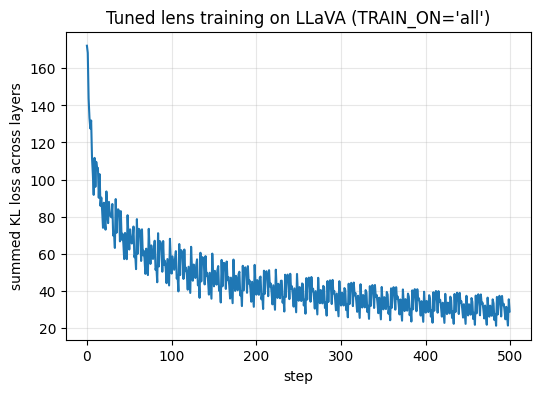

In [9]:
translator_device = next(translators.parameters()).device

optimizer = torch.optim.SGD(translators.parameters(), lr=0.1, momentum=0.0)
NUM_EPOCHS = 20

loss_curve = []
step = 0
for epoch in range(NUM_EPOCHS):
    for path in IMAGE_PATHS:
        image = load_image(path)
        inputs = build_inputs(image)

        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
            target_probs_full = F.softmax(outputs.logits.float(), dim=-1)

        image_token_id = model.config.image_token_index
        image_token_positions = (inputs["input_ids"][0] == image_token_id).nonzero(as_tuple=True)[0]
        positions = select_training_positions(inputs["input_ids"][0], image_token_positions, TRAIN_ON)

        optimizer.zero_grad()
        total_loss_value = 0.0
        for i in range(n_layer):
            h = outputs.hidden_states[i][0, positions, :].to(translator_device)
            target_probs = target_probs_full[0, positions, :].to(translator_device)
            layer_loss = translator_loss(translators.layers[i], h, target_probs, ln_f, lm_head)
            layer_loss.backward()
            total_loss_value += layer_loss.item()

        torch.nn.utils.clip_grad_norm_(translators.parameters(), max_norm=1.0)
        optimizer.step()

        loss_curve.append(total_loss_value)
        if step % 5 == 0:
            print(f"step {step} (epoch {epoch}): total loss {total_loss_value:.4f}")
        step += 1

plt.figure(figsize=(6, 4))
plt.plot(loss_curve)
plt.xlabel("step")
plt.ylabel("summed KL loss across layers")
plt.title(f"Tuned lens training on LLaVA (TRAIN_ON={TRAIN_ON!r})")
plt.grid(alpha=0.3)
plt.savefig("/kaggle/working/day4_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()